# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

Note: you may need to restart the kernel to use updated packages.


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [5]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [13]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [7]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

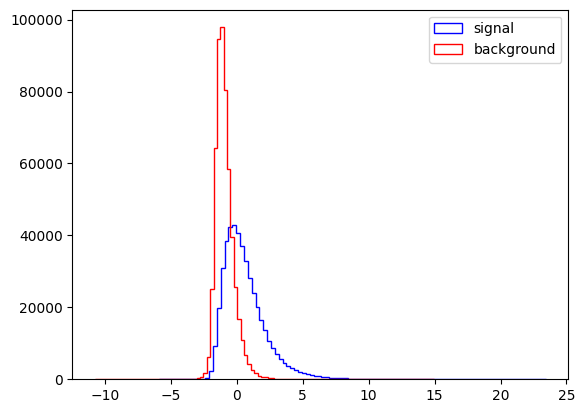

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

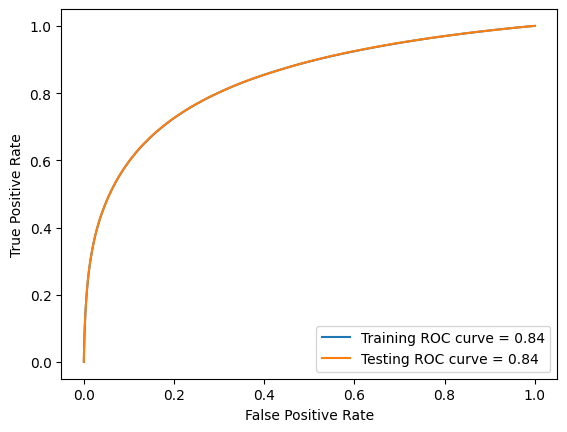

In [14]:
from sklearn.metrics import roc_curve, auc

try_training_scores = Fisher.decision_function(X_Train) # Get the classifier score for each training event
try_testing_scores = Fisher.decision_function(X_Test) # Grab the classifier score for each testing event.

fpr_train, tpr_train, _ = roc_curve(y_Train, try_training_scores) # Make the ROC Curve for the training sample.
fpr_test, tpr_test, _ = roc_curve(y_Test, try_testing_scores) # Make the ROC Curve for the testing sample.

auc_train = auc(fpr_train, tpr_train) # Calculate the area underneath each ROC curve for the training sample
auc_test = auc(fpr_test, tpr_test) # Calculate the area underneath each ROC curve for the testing sample

plt.figure() # Start a plot

plt.plot(fpr_train, tpr_train, label = 'Training ROC curve = %0.2f' % auc_train) # Plots the ROC curve from the training sample.
plt.plot(fpr_test, tpr_test, label = 'Testing ROC curve = %0.2f' % auc_test) # Plots the ROC curve from the testing sample.

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc = "lower right")
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [ ]:
My question was: "How do I train the fisher performance here & What is this question asking me to do fully - What raw, features and raw+features is it talking about? And can you show me an outline of what it would look like to help steer me in the right direction?"

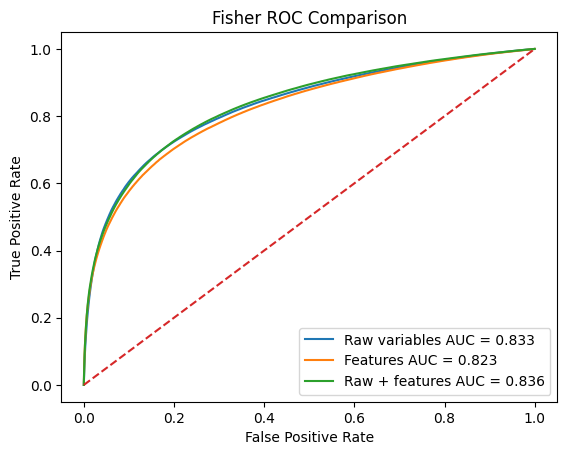

In [15]:
from sklearn.metrics import roc_curve, auc
import sklearn.discriminant_analysis as DA

# Define the three groups of input variables
RawNames = VarNames[1:9] # Raw variables are the first 8 input variables after the signal column
FeatureNames = VarNames[9:] # High level & engineered features (more input variables)
AllNames = VarNames[1:] # Raw + High-level features (all input variables)

def fisher_roc(feature_list): # Trains fisher & returns the ROC curve

    Fisher_model = DA.LinearDiscriminantAnalysis() # Creates a new classifier

    Fisher_model.fit(Train_Sample[feature_list], y_Train) # Trains the classifier on only the chosen features.

    scores = Fisher_model.decision_function(Test_Sample[feature_list]) # Grabs the classifier scores based on the test sample.

    fpr, tpr, _ = roc_curve(y_Test, scores) # Makes the ROC curve based off of the test labels and test scores.

    roc_auc = auc(fpr, tpr) # Calculates the area underneath the ROC curve

    return fpr, tpr, roc_auc # Returns ...?

fpr_raw, tpr_raw, auc_raw = fisher_roc(RawNames) # Trains fisher using raw variables only
fpr_feat, tpr_feat, auc_feat = fisher_roc(FeatureNames) # Trains fisher using high level features only
fpr_all, tpr_all, auc_all = fisher_roc(AllNames) # Trains fisher using raw & high level features 

plt.figure()

plt.plot(fpr_raw, tpr_raw, label="Raw variables AUC = %0.3f" % auc_raw)
plt.plot(fpr_feat, tpr_feat, label="Features AUC = %0.3f" % auc_feat)
plt.plot(fpr_all, tpr_all, label="Raw + features AUC = %0.3f" % auc_all)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC Comparison")
plt.legend(loc="lower right")
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

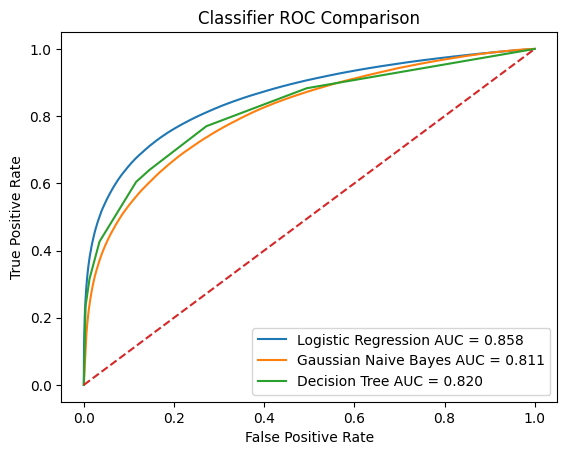

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

def make_roc(evaluate): # Trains one classifier and returns its ROC curve value to the plot
    evaluate.fit(X_Train, y_Train) # Trains the classifier with the training data.
    scores = evaluate.predict_proba(X_Test)[:, 1] #Then grabs the probability of each test that has signal.
    fpr, tpr, _ = roc_curve(y_Test, scores) # Makes the ROC curve using the test labels and classifier scores given
    return fpr, tpr, auc(fpr, tpr) # Returns the ROC + curve values and area under the curve

classifiers = [(LogisticRegression(max_iter=1000), "Logistic Regression"), (GaussianNB(), "Gaussian Naive Bayes"),
               (DecisionTreeClassifier(max_depth=3), "Decision Tree")] # These are the classifiers I'm comparing

plt.figure()

for evaluate, name in classifiers: # Loops each classifier
    fpr, tpr, roc_auc = make_roc(evaluate) #Trains the classifier and gets it's ROC curve and AUC
    plt.plot(fpr, tpr, label = "%s AUC = %0.3f" % (name, roc_auc)) # Then plot's this classifier's ROC curve

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier ROC Comparison")
plt.legend(loc = "lower right")
plt.show()

In [17]:
import numpy as np

best_classifier = LogisticRegression(max_iter=1000) 
best_classifier.fit(X_Train, y_Train) # Train the classifier

scores = best_classifier.predict_proba(X_Test)[:, 1] # Grab classifier scores for the test sample
cuts = np.linspace(scores.min(), scores.max(), 100) # Store all cut values

significances = [] # Store significance values

for cut in cuts: # Loop through each cut value
    passed = scores > cut # Events that pass the cut
    N_S = np.sum((y_Test == 1) & passed) # Count all signal events that pass
    N_B = np.sum((y_Test == 0) & passed) # Count all background events that pass
    
    if N_S + N_B > 0: # Avoid dividing by zero
        sigma_s = N_S / np.sqrt(N_S + N_B) # Calculate significance
    else:
        sigma_s = 0 # Mark 0 if no events pass cut
    
    significances.append(sigma_s) # Save the significance

max_significance = max(significances) # Find the largest significance
best_cut = cuts[np.argmax(significances)] # Find the cut value that gives the largest significance

print("Best cut:", best_cut)
print("Maximum significance:", max_significance)

Best cut: 0.36363636382708825
Maximum significance: 516.6561896666952


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

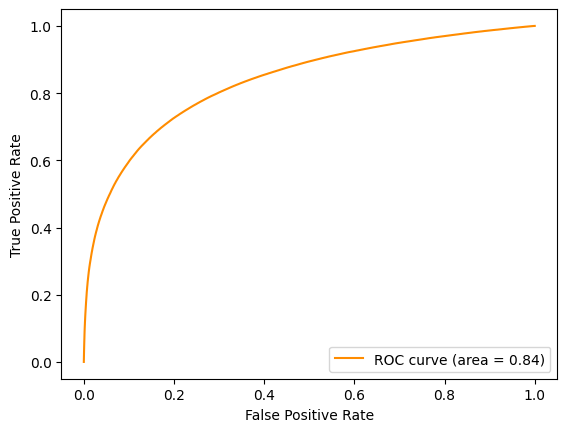

In [18]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [20]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd

best_classifier = LogisticRegression(max_iter=1000)
best_classifier.fit(X_Train, y_Train) # Training the classifier w/ the training data

scores = best_classifier.predict_proba(X_Test)[:, 1] # Calculates the probability of each test event being signal
fpr, tpr, cuts = roc_curve(y_Test, scores) # Makes the ROCC curve and then stores the cut values.
roc_auc = auc(fpr, tpr) # Calculates the area underneath the ROC curve

significances = [] # Store significance values

for cut in cuts: # Loop through each cut val
    passed = scores >= cut # Events that pass the cut
    N_S = np.sum((y_Test == 1) & passed) # Count all signal events that pass
    N_B = np.sum((y_Test == 0) & passed) # Count all background events that pass
    significances.append(N_S / np.sqrt(N_S + N_B) if N_S + N_B > 0 else 0) #Saves the significance

best_i = np.argmax(significances) # Finds the cut with the largest significance
best_cut = cuts[best_i] # Stores the best cut value
y_pred = scores > best_cut #Classifies events using the best cut

# Makes a table of the results
results = pd.DataFrame({"Method": ["Logistic Regression"], "TPR": [tpr[best_i]], "FPR": [fpr[best_i]], "AUC": [roc_auc],
                        "Precision": [precision_score(y_Test, y_pred)], "Recall": [recall_score(y_Test, y_pred)],
                        "F1 Score": [f1_score(y_Test, y_pred)], "Accuracy": [accuracy_score(y_Test, y_pred)],
                        "Max Significance": [significances[best_i]]})

results # Shows the table

,Method,TPR,FPR,AUC,Precision,Recall,F1 Score,Accuracy,Max Significance
0,Logistic Regression,0.787115,0.233737,0.858159,0.740144,0.787113,0.762906,0.775817,516.678596
